In [5]:
# EDA — Transport Sector GHG Emissions Dashboard
# Goal: Surface 3-5 key insights to showcase in the Streamlit dashboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Robust path setup — walks up until it finds the 'data' folder
def find_project_root():
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / "data" / "processed").exists():
            return parent
    raise FileNotFoundError("Could not locate project root with 'data/processed' folder")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:  {DATA_DIR}")

df = pd.read_csv(DATA_DIR / "emissions_clean.csv")
df_world = pd.read_csv(DATA_DIR / "emissions_aggregates.csv")

print(f"\nCountry data: {df.shape}")
print(f"Aggregate data: {df_world.shape}")
df.head()

Project root: C:\Users\DELL\Desktop\Data Science
Data folder:  C:\Users\DELL\Desktop\Data Science\data\processed

Country data: (6037, 8)
Aggregate data: (64, 4)


,country_code,country,year,emissions_mtco2e,continent,region,yoy_change_pct,decade
0,AFG,Afghanistan,1990,0.97,Asia,Asia,NaN,1990
1,AFG,Afghanistan,1991,0.93,Asia,Asia,-4.12,1990
2,AFG,Afghanistan,1992,0.74,Asia,Asia,-20.43,1990
3,AFG,Afghanistan,1993,0.74,Asia,Asia,0.00,1990
4,AFG,Afghanistan,1994,0.73,Asia,Asia,-1.35,1990


In [6]:
# Check for duplicates
print("Total rows:", len(df))
print("Unique (country, year) combinations:", len(df[['country', 'year']].drop_duplicates()))
print("\nDuplicate rows count:", df.duplicated().sum())
print("Duplicate (country, year) count:", df.duplicated(subset=['country', 'year']).sum())

# Show a sample of duplicates
print("\nSample duplicates:")
print(df[df.duplicated(subset=['country', 'year'], keep=False)].head(10))

Total rows: 6037
Unique (country, year) combinations: 6037

Duplicate rows count: 0
Duplicate (country, year) count: 0

Sample duplicates:
Empty DataFrame
Columns: [country_code, country, year, emissions_mtco2e, continent, region, yoy_change_pct, decade]
Index: []


In [7]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== YEAR RANGE ===")
print(f"{df['year'].min()} to {df['year'].max()} ({df['year'].nunique()} years)")

print("\n=== CONTINENT DISTRIBUTION ===")
print(df['continent'].value_counts())

=== DATA TYPES ===
country_code            str
country                 str
year                  int64
emissions_mtco2e    float64
continent               str
region                  str
yoy_change_pct      float64
decade                int64
dtype: object

=== MISSING VALUES ===
country_code          0
country               0
year                  0
emissions_mtco2e      0
continent             0
region                0
yoy_change_pct      287
decade                0
dtype: int64

=== YEAR RANGE ===
1990 to 2021 (32 years)

=== CONTINENT DISTRIBUTION ===
continent
Africa           1693
Asia             1457
Europe           1233
North America     736
Oceania           512
South America     374
Unknown            32
Name: count, dtype: int64


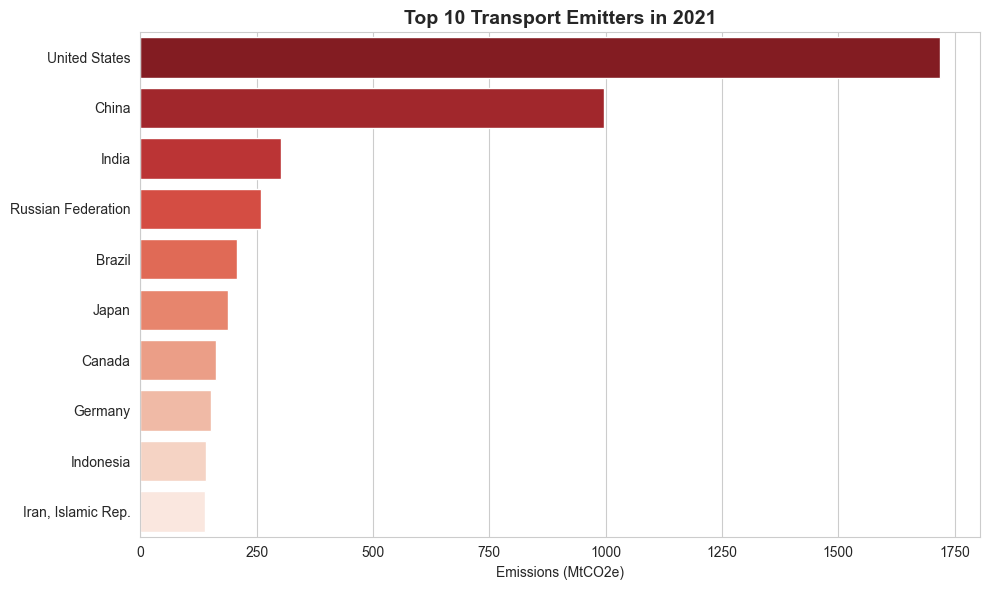


 KEY INSIGHT 1:
Top 3 emitters in 2021: United States, China, India
Top 10 countries = 62.9% of global transport emissions


In [9]:
latest_year = df['year'].max()
top10 = df[df['year'] == latest_year].nlargest(10, 'emissions_mtco2e')

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, y='country', x='emissions_mtco2e',
            hue='country', legend=False, palette='Reds_r')
plt.title(f'Top 10 Transport Emitters in {latest_year}', fontsize=14, fontweight='bold')
plt.xlabel('Emissions (MtCO2e)')
plt.ylabel('')
plt.tight_layout()
plt.show()

total_top10 = top10['emissions_mtco2e'].sum()
total_all = df[df['year'] == latest_year]['emissions_mtco2e'].sum()
print(f"\n KEY INSIGHT 1:")
print(f"Top 3 emitters in {latest_year}: {', '.join(top10['country'].head(3).tolist())}")
print(f"Top 10 countries = {(total_top10/total_all)*100:.1f}% of global transport emissions")

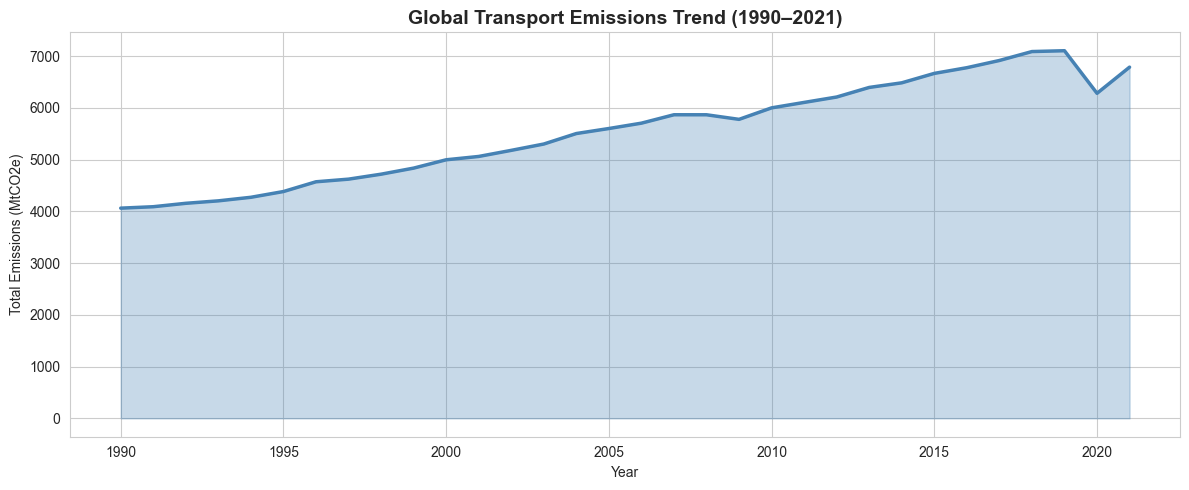


 KEY INSIGHT 2:
Global transport emissions grew by 67.1% from 1990 to 2021
Absolute increase: 2725 MtCO2e


In [11]:
global_trend = df.groupby('year')['emissions_mtco2e'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.fill_between(global_trend['year'], global_trend['emissions_mtco2e'],
                 alpha=0.3, color='steelblue')
plt.plot(global_trend['year'], global_trend['emissions_mtco2e'],
         linewidth=2.5, color='steelblue')
plt.title('Global Transport Emissions Trend (1990–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Emissions (MtCO2e)')
plt.tight_layout()
plt.show()

start_val = global_trend.iloc[0]['emissions_mtco2e']
end_val = global_trend.iloc[-1]['emissions_mtco2e']
pct_change = ((end_val - start_val) / start_val) * 100
print(f"\n KEY INSIGHT 2:")
print(f"Global transport emissions grew by {pct_change:.1f}% from 1990 to 2021")
print(f"Absolute increase: {(end_val-start_val):.0f} MtCO2e")

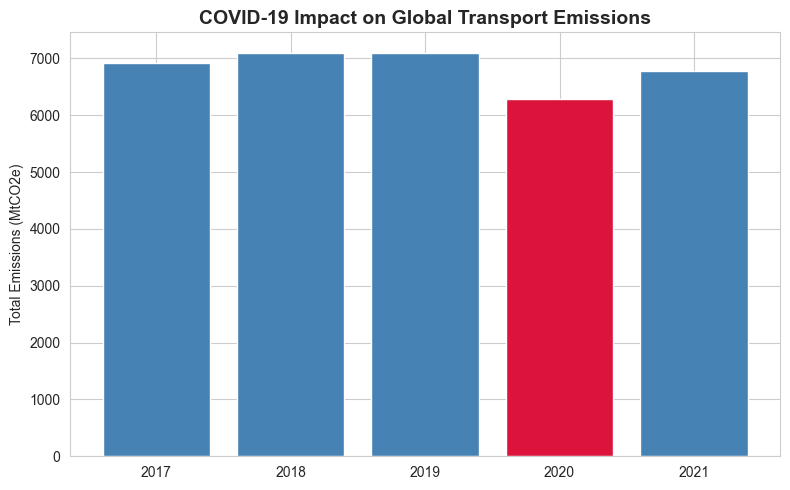


 KEY INSIGHT 3:
 The COVID-19 impact: Emissions dropped by -11.58% from 2019 to 2020
Partial recovery: +8.05% from 2020 to 2021


In [12]:
pivot = df.groupby('year')['emissions_mtco2e'].sum()
drop_2020 = ((pivot[2020] - pivot[2019]) / pivot[2019]) * 100
recovery_2021 = ((pivot[2021] - pivot[2020]) / pivot[2020]) * 100

recent = pivot.loc[2017:2021]
plt.figure(figsize=(8, 5))
colors = ['steelblue' if y != 2020 else 'crimson' for y in recent.index]
plt.bar(recent.index.astype(str), recent.values, color=colors)
plt.title('COVID-19 Impact on Global Transport Emissions', fontsize=14, fontweight='bold')
plt.ylabel('Total Emissions (MtCO2e)')
plt.tight_layout()
plt.show()

print(f"\n KEY INSIGHT 3:")
print(f" The COVID-19 impact: Emissions dropped by {drop_2020:.2f}% from 2019 to 2020")
print(f"Partial recovery: +{recovery_2021:.2f}% from 2020 to 2021")

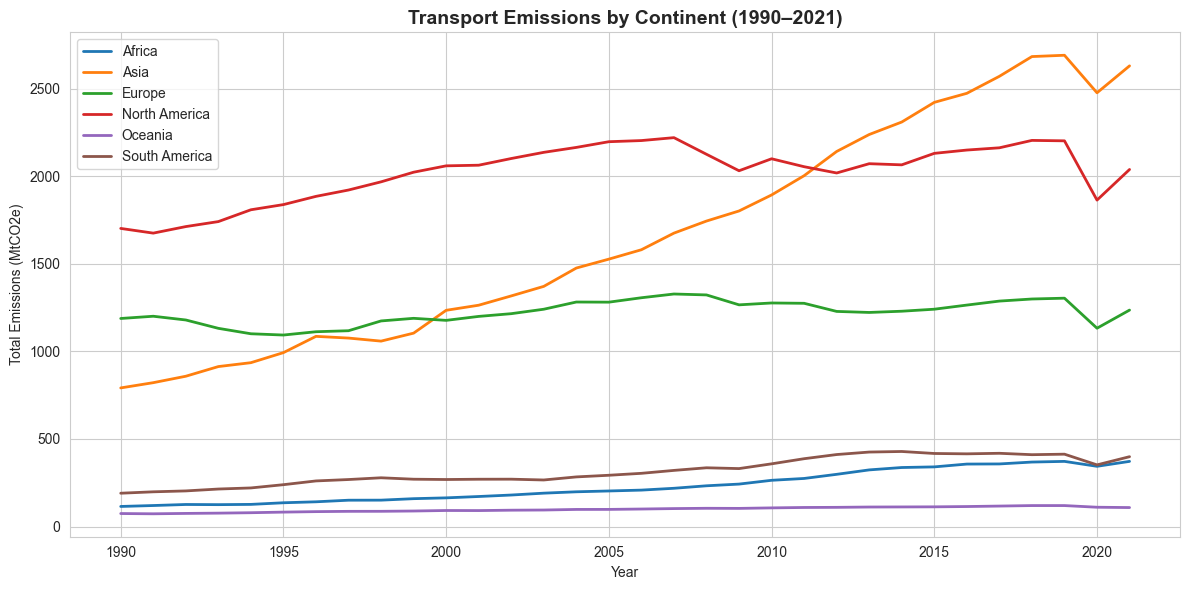


 KEY INSIGHT 4:
Continent ranking in 2021:
continent
Asia             2631.2
North America    2039.4
Europe           1236.3
South America     398.9
Africa            372.1
Oceania           108.3
Unknown             0.3


In [13]:
continent_trend = df[df['continent'] != 'Unknown'].groupby(
    ['year', 'continent']
)['emissions_mtco2e'].sum().reset_index()

plt.figure(figsize=(12, 6))
for continent in continent_trend['continent'].unique():
    data = continent_trend[continent_trend['continent'] == continent]
    plt.plot(data['year'], data['emissions_mtco2e'],
             label=continent, linewidth=2)

plt.title('Transport Emissions by Continent (1990–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Emissions (MtCO2e)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

latest_by_continent = df[df['year'] == latest_year].groupby(
    'continent'
)['emissions_mtco2e'].sum().sort_values(ascending=False)

print(f"\n KEY INSIGHT 4:")
print(f"Continent ranking in {latest_year}:")
print(latest_by_continent.round(1).to_string())

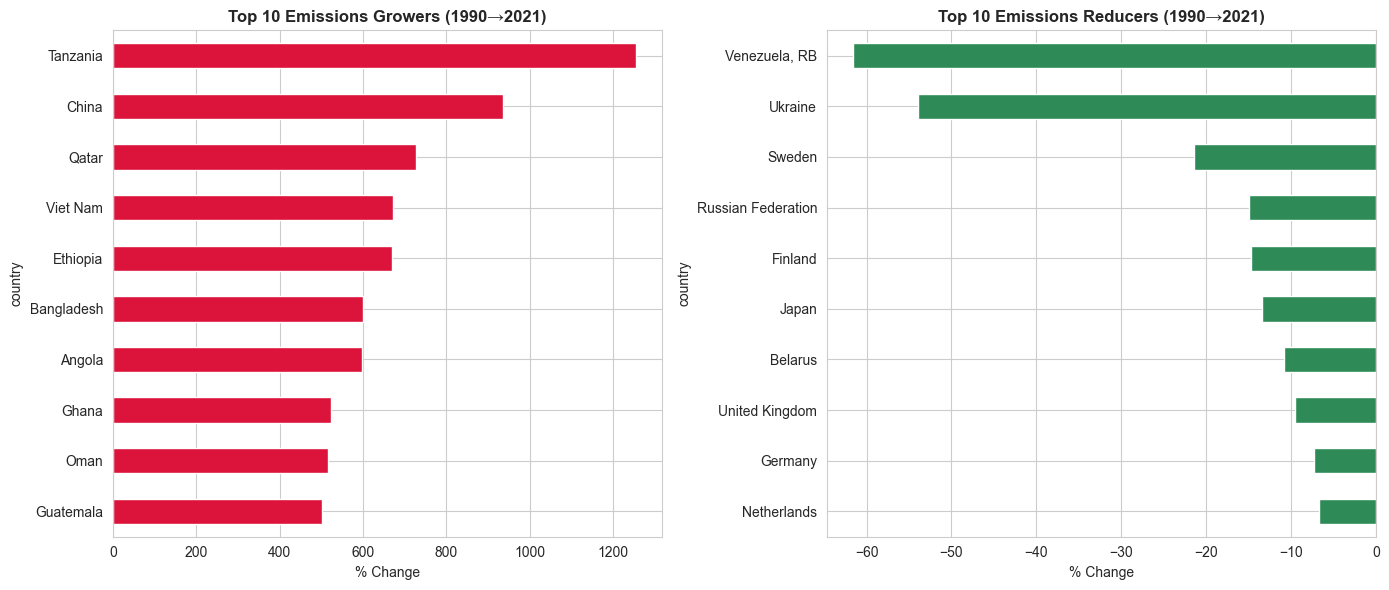


 KEY INSIGHT 5:
Biggest grower: Tanzania (+1254%)
Biggest reducer: Venezuela, RB (-62%)


In [15]:
wide = df.pivot_table(index='country', columns='year', values='emissions_mtco2e')
wide['pct_change'] = ((wide[2021] - wide[1990]) / wide[1990]) * 100
wide_clean = wide.dropna(subset=['pct_change'])
wide_clean = wide_clean[wide_clean[2021] >= 5]   # filter tiny countries

top_growers = wide_clean.nlargest(10, 'pct_change')[['pct_change']]
top_reducers = wide_clean.nsmallest(10, 'pct_change')[['pct_change']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_growers.plot(kind='barh', ax=axes[0], color='crimson', legend=False)
axes[0].set_title('Top 10 Emissions Growers (1990→2021)', fontweight='bold')
axes[0].set_xlabel('% Change')
axes[0].invert_yaxis()

top_reducers.plot(kind='barh', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('Top 10 Emissions Reducers (1990→2021)', fontweight='bold')
axes[1].set_xlabel('% Change')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n KEY INSIGHT 5:")
print(f"Biggest grower: {top_growers.index[0]} (+{top_growers.iloc[0, 0]:.0f}%)")
print(f"Biggest reducer: {top_reducers.index[0]} ({top_reducers.iloc[0, 0]:.0f}%)")

In [16]:
latest_df = df[df['year'] == latest_year]

fig = px.choropleth(
    latest_df,
    locations='country_code',
    color='emissions_mtco2e',
    hover_name='country',
    color_continuous_scale='Reds',
    title=f'Global Transport Emissions, {latest_year}',
    labels={'emissions_mtco2e': 'MtCO2e'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

In [18]:
print("KEY INSIGHTS FOR STREAMLIT DASHBOARD")
print(f"""
1. TOP EMITTERS — A small number of countries dominate.
   Top 3 in {latest_year}: {', '.join(top10['country'].head(3).tolist())}

2. GLOBAL TREND — Emissions grew {pct_change:.1f}% since 1990.

3. COVID DIP — A visible drop in 2020 ({drop_2020:.1f}%),
   partial recovery ({recovery_2021:.1f}%) by 2021.

4. CONTINENT SHIFT — Asia has emerged as the biggest contributor.

5. DIVERGENT TRAJECTORIES —
   Biggest grower: {top_growers.index[0]} (+{top_growers.iloc[0, 0]:.0f}%)
   Biggest reducer: {top_reducers.index[0]} ({top_reducers.iloc[0, 0]:.0f}%)

DASHBOARD PAGES TO BUILD:
- Page 1: Global Overview (world map, KPIs, top 10 bar chart)
- Page 2: Country Comparison (multi-select, line chart)
- Page 3: Trends & Forecast (continent lines, projection to 2030)
- Page 4: Data Explorer (filterable table with downloads)
""")

KEY INSIGHTS FOR STREAMLIT DASHBOARD

1. TOP EMITTERS — A small number of countries dominate.
   Top 3 in 2021: United States, China, India

2. GLOBAL TREND — Emissions grew 67.1% since 1990.

3. COVID DIP — A visible drop in 2020 (-11.6%),
   partial recovery (8.0%) by 2021.

4. CONTINENT SHIFT — Asia has emerged as the biggest contributor.

5. DIVERGENT TRAJECTORIES —
   Biggest grower: Tanzania (+1254%)
   Biggest reducer: Venezuela, RB (-62%)

DASHBOARD PAGES TO BUILD:
- Page 1: Global Overview (world map, KPIs, top 10 bar chart)
- Page 2: Country Comparison (multi-select, line chart)
- Page 3: Trends & Forecast (continent lines, projection to 2030)
- Page 4: Data Explorer (filterable table with downloads)

